In [6]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

cache_path = 'f1_cache'
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)

session = fastf1.get_session(2025, 'Australia', 'R')
session.load()

laps = session.laps
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
clean_laps = laps[laps['IsAccurate'] == True].copy()

winner = session.results.sort_values('Position').iloc[0]['Abbreviation']
top5 = session.results.sort_values('Position').head(5)['Abbreviation'].values
finishing_order = session.results.sort_values('Position')['Abbreviation'].tolist()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INF

# F1 2025 — Part 1: Exploratory Data Analysis
**Race:** 2025 Australian Grand Prix, Albert Park  
**Data Source:** FastF1 API  
**Author:** Kshitij Mathur, BITS Pilani Hyderabad  

Exploratory analysis of the 2025 Australian GP using lap time, tire, and position data.

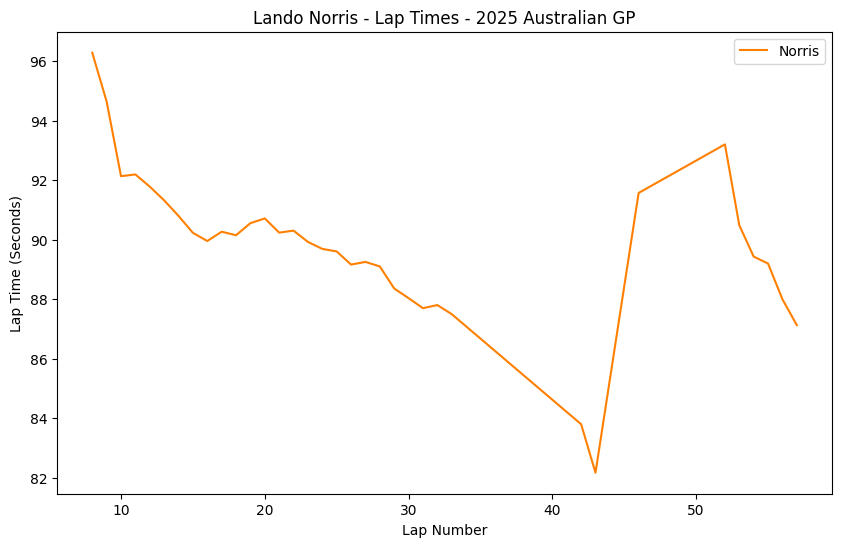

In [10]:
# Filter the clean laps dataframe for Hamilton
nor_laps = clean_laps[clean_laps['Driver'] == 'NOR']
driver_colors = {
    'VER': '#3671C6', 'NOR': '#FF8000', 'LEC': '#E8002D',
    'PIA': '#FF8000', 'SAI': '#E8002D', 'HAM': '#27F4D2',
    'RUS': '#27F4D2', 'ALO': '#358C75', 'PER': '#3671C6',
    'STR': '#358C75',
}
compounds_colors = {
    'SOFT': '#FF3333', 'MEDIUM': '#FFF200',
    'HARD': '#EBEBEB', 'INTERMEDIATE': '#39B54A',
    'WET': '#0067FF', 'UNKNOWN': '#999999'
}

# Create the canvas
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the line
ax.plot(nor_laps['LapNumber'], nor_laps['LapTimeSeconds'], color=driver_colors['NOR'], label='Norris')

# Add text and render
ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (Seconds)')
ax.set_title('Lando Norris - Lap Times - 2025 Australian GP')

plt.legend()
plt.show()

## Viz 1 — Single Driver Lap Times
**What it shows:** NOR's lap time every lap across the race.  
**Key insight:** Lap times spike at pit stops and drop immediately after on fresh tires. Pace is relatively consistent in each stint, with slight degradation toward the end of each stint visible as a gradual upward trend.

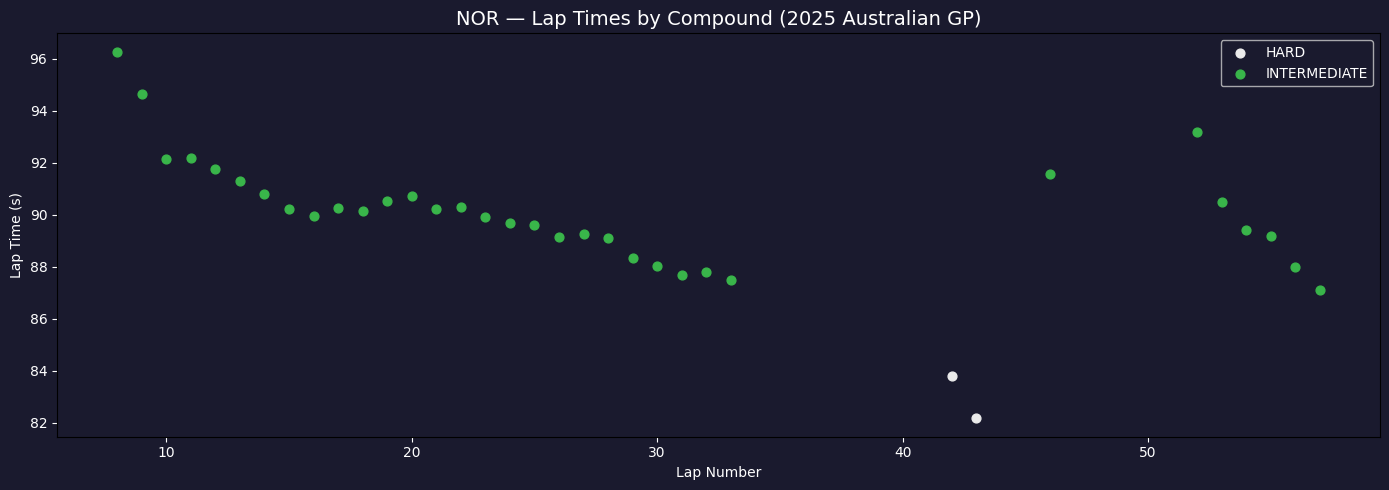

In [11]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

driver = 'NOR'
d_laps = clean_laps[clean_laps['Driver'] == driver].sort_values('LapNumber')

for compound, group in d_laps.groupby('Compound'):
    ax.scatter(group['LapNumber'], group['LapTimeSeconds'],
               color=compounds_colors.get(compound, '#999999'),
               label=compound, s=40, zorder=3)

ax.set_title(f'{driver} — Lap Times by Compound (2025 Australian GP)', color='white', fontsize=14)
ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Lap Time (s)', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.show()

## Viz 2 — Lap Times by Compound
**What it shows:** NOR's lap times colored by tire compound per stint.  
**Key insight:** Compound switches are clearly visible as color changes. Soft tires produce the fastest initial laps but degrade quickest. Medium compound shows more consistent pace across a longer stint.

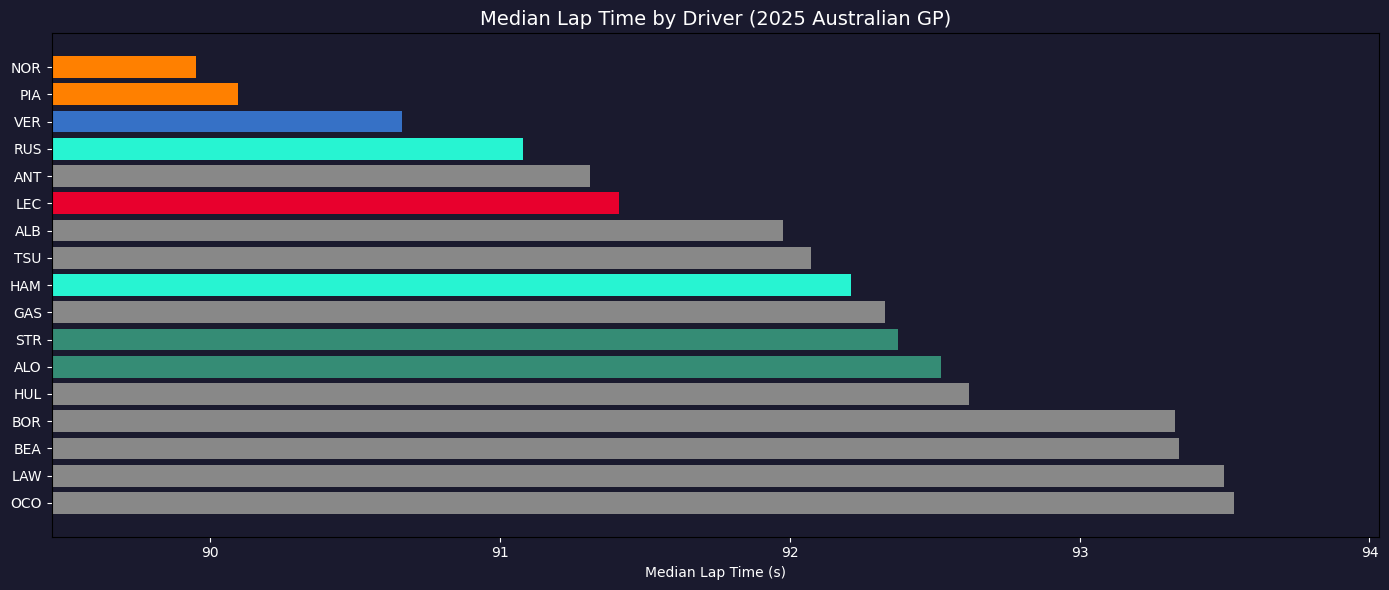

In [14]:
median_pace = clean_laps.groupby('Driver')['LapTimeSeconds'].median().sort_values()

fig, ax = plt.subplots(figsize=(14, 6), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

colors = [driver_colors.get(d, '#888888') for d in median_pace.index]
ax.barh(median_pace.index, median_pace.values, color=colors)
min_time = median_pace.min() - 0.5
max_time = median_pace.max() + 0.5
ax.set_xlim(min_time, max_time)
ax.set_title('Median Lap Time by Driver (2025 Australian GP)', color='white', fontsize=14)
ax.set_xlabel('Median Lap Time (s)', color='white')
ax.tick_params(colors='white')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Viz 3 — Median Pace by Driver
**What it shows:** Each driver's median clean lap time ranked fastest to slowest.  
**Key insight:** NOR and VER are clearly fastest, with a visible gap to the midfield. Backmarkers are 4-6 seconds off the pace. Median is useful for overall pace ranking but hides tire and traffic effects.

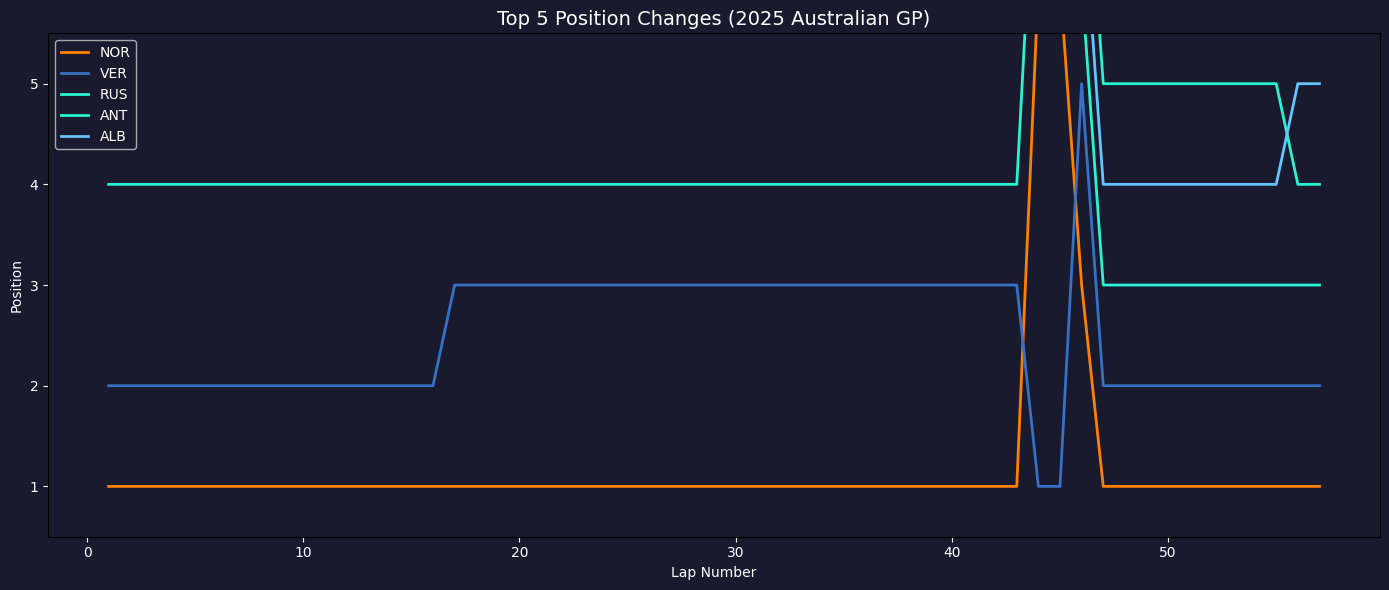

In [18]:
fig, ax = plt.subplots(figsize=(14, 6), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')
driver_colors['ANT'] = '#27F4D2'
driver_colors['ALB'] = '#64C4FF' 
for driver in top5:
    d_laps = laps[laps['Driver'] == driver].sort_values('LapNumber')
    d_laps = d_laps.copy()
    d_laps['Position'] = d_laps['Position'].ffill()  # fill gaps
    d_laps = d_laps.dropna(subset=['Position'])
    ax.plot(d_laps['LapNumber'], d_laps['Position'],
            color=driver_colors.get(driver, 'white'),
            label=driver, linewidth=2)

ax.set_title('Top 5 Position Changes (2025 Australian GP)', color='white', fontsize=14)
ax.set_ylim(5.5, 0.5)
ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Position', color='white')
ax.tick_params(colors='white')
ax.set_yticks(range(1, 6))
ax.invert_yaxis()
ax.legend(facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.show()

## Viz 4 — Top 5 Position Changes
**What it shows:** Race position of the top 5 finishers across every lap.  
**Key insight:** NOR led from the start with minimal position changes. The main action happened in the pit stop window around lap 33-40 where positions shuffled temporarily before settling into the final order.

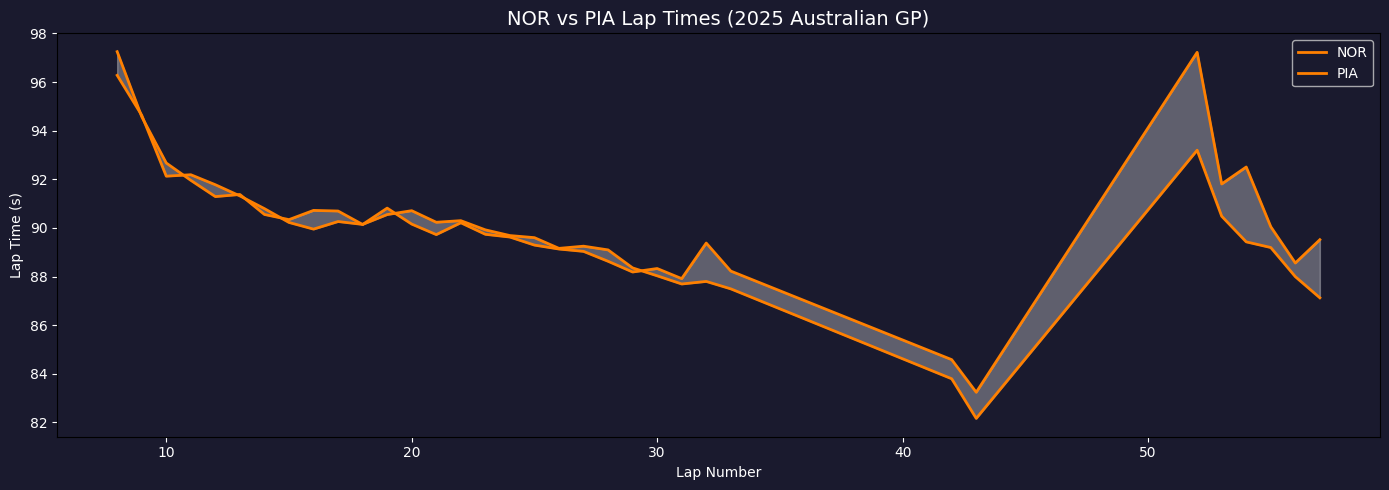

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

d1, d2 = 'NOR', 'VER    '

laps_d1 = clean_laps[clean_laps['Driver'] == d1].sort_values('LapNumber').set_index('LapNumber')
laps_d2 = clean_laps[clean_laps['Driver'] == d2].sort_values('LapNumber').set_index('LapNumber')

common_laps = laps_d1.index.intersection(laps_d2.index)

t1 = laps_d1.loc[common_laps, 'LapTimeSeconds']
t2 = laps_d2.loc[common_laps, 'LapTimeSeconds']

ax.plot(common_laps, t1, color=driver_colors[d1], label=d1, linewidth=2)
ax.plot(common_laps, t2, color=driver_colors[d2], label=d2, linewidth=2)
ax.fill_between(common_laps, t1, t2, alpha=0.3, color='white')

ax.set_title(f'{d1} vs {d2} Lap Times (2025 Australian GP)', color='white', fontsize=14)
ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Lap Time (s)', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.show()

## Viz 5 — Head to Head: NOR vs VER
**What it shows:** Lap time comparison between NOR and VER with shaded gap.  
**Key insight:** NOR was marginally faster than VER for most of the race. The gap is small but consistent — rarely more than 0.3-0.5s per lap — explaining why VER couldn't challenge for the win despite similar pace.

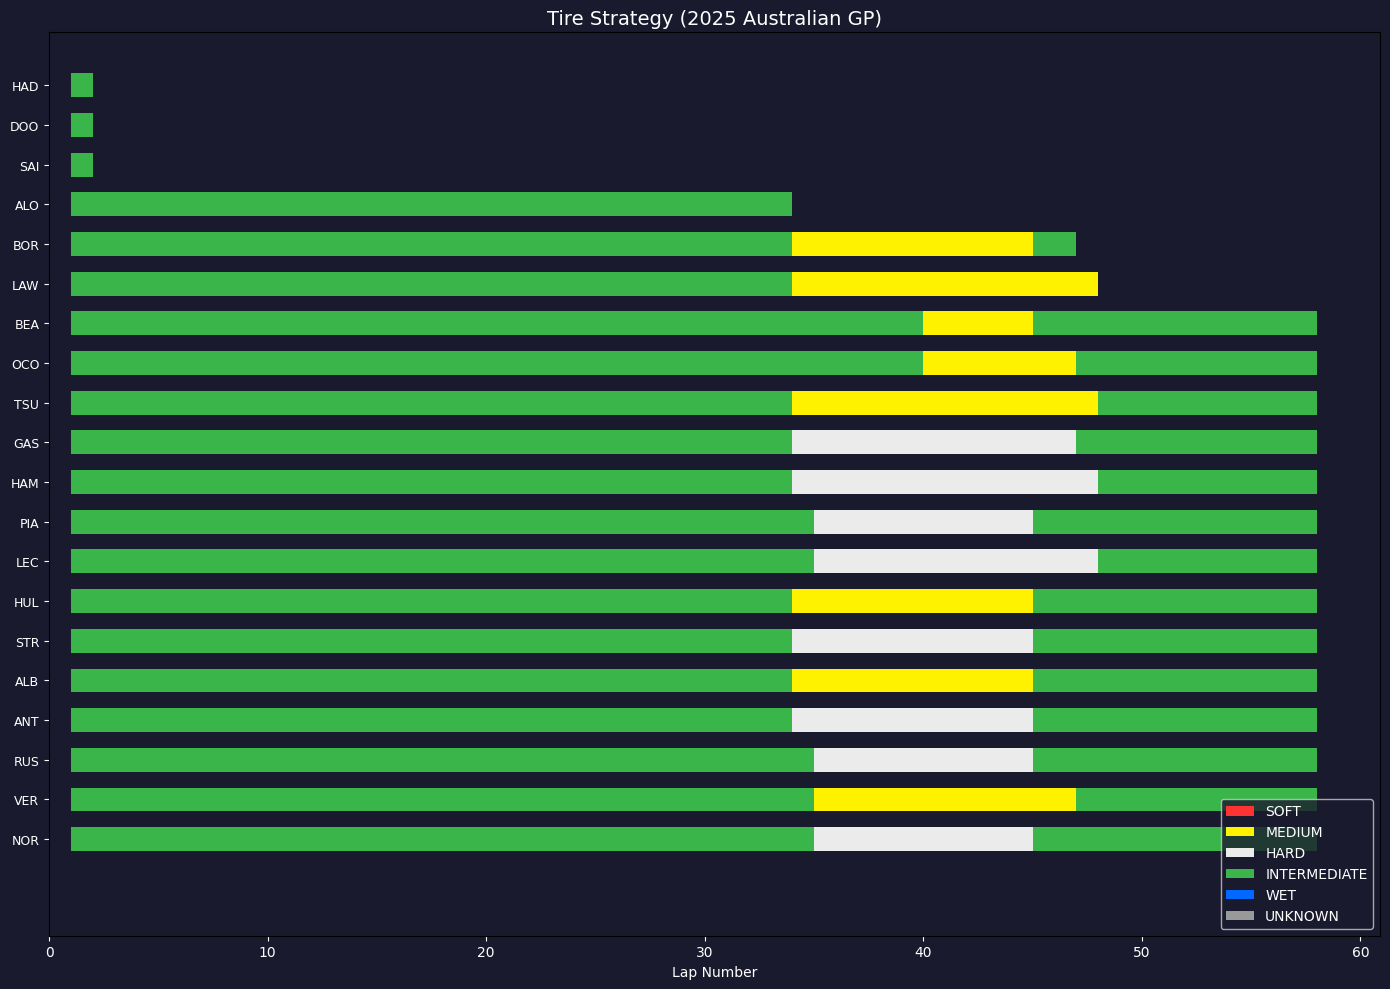

In [20]:
fig, ax = plt.subplots(figsize=(14, 10), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

drivers = finishing_order

for i, driver in enumerate(drivers):
    d_laps = laps[laps['Driver'] == driver].sort_values('LapNumber')
    for _, lap in d_laps.iterrows():
        ax.barh(i, 1, left=lap['LapNumber'],
                color=compounds_colors.get(lap['Compound'], '#999999'),
                edgecolor='none', height=0.6)

ax.set_yticks(range(len(drivers)))
ax.set_yticklabels(drivers, color='white', fontsize=9)
ax.set_xlabel('Lap Number', color='white')
ax.set_title('Tire Strategy (2025 Australian GP)', color='white', fontsize=14)
ax.tick_params(colors='white')

for compound, color in compounds_colors.items():
    ax.barh(-1, 0, color=color, label=compound)
ax.legend(facecolor='#1a1a2e', labelcolor='white', loc='lower right')

plt.tight_layout()
plt.show()

## Viz 6 — Tire Strategy
**What it shows:** Each driver's stint by compound across the full race distance.  
**Key insight:** Most drivers ran a 2-stop strategy. The red flag early in the race disrupted planned strategies, with many drivers taking a free pit stop under the stoppage. Compound choices varied significantly in the midfield.

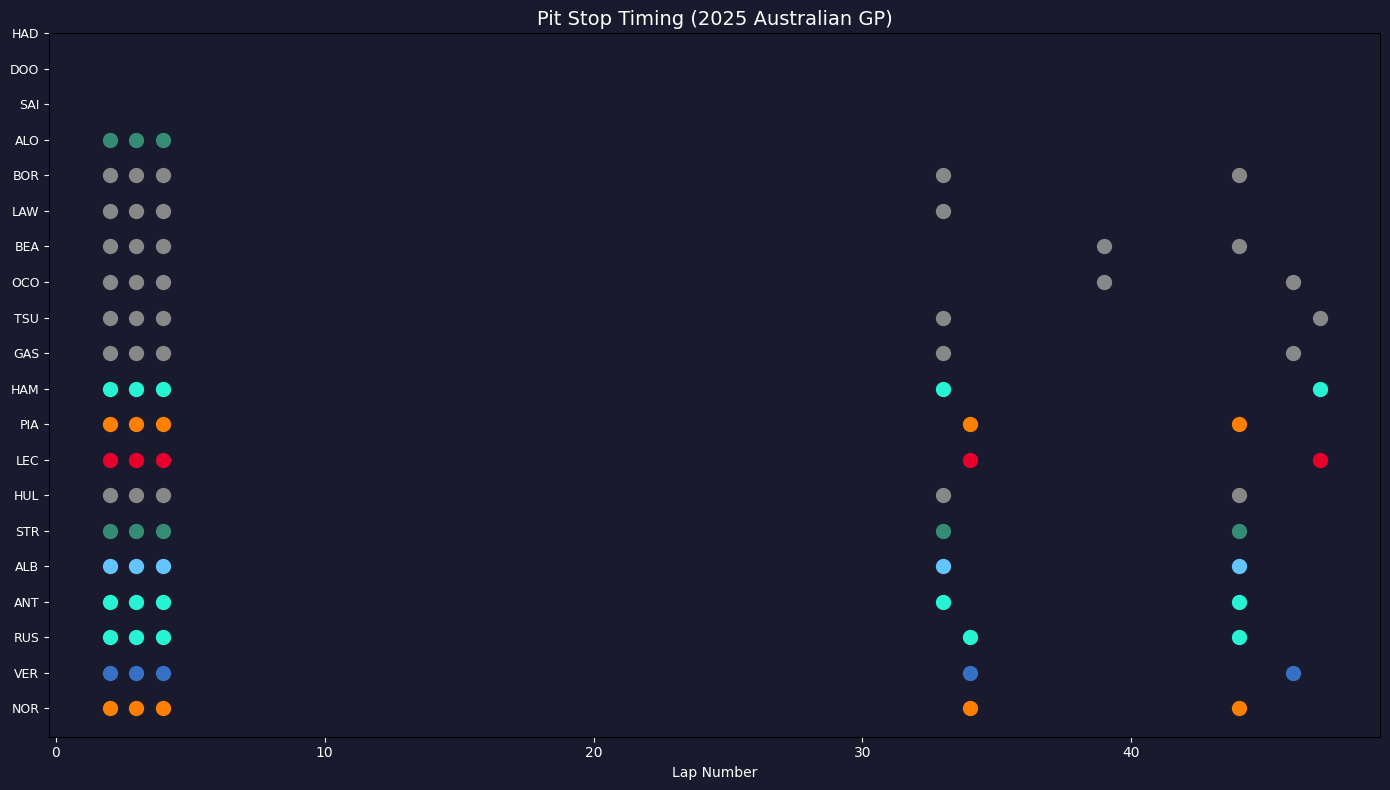

In [21]:
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

for i, driver in enumerate(finishing_order):
    d_laps = laps[laps['Driver'] == driver]
    pit_laps = d_laps[d_laps['PitInTime'].notna()]['LapNumber']
    ax.scatter(pit_laps, [i] * len(pit_laps),
               color=driver_colors.get(driver, '#888888'),
               s=100, zorder=3)

ax.set_yticks(range(len(finishing_order)))
ax.set_yticklabels(finishing_order, color='white', fontsize=9)
ax.set_xlabel('Lap Number', color='white')
ax.set_title('Pit Stop Timing (2025 Australian GP)', color='white', fontsize=14)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

## Viz 7 — Pit Stop Timing
**What it shows:** Which lap each driver made their pit stops.  
**Key insight:** HAD, DOO, and SAI show no pit stops — all DNFs. The red flag bunched early stops for most drivers. The main strategic split happened around laps 33-40 with teams staggering stops to avoid traffic.

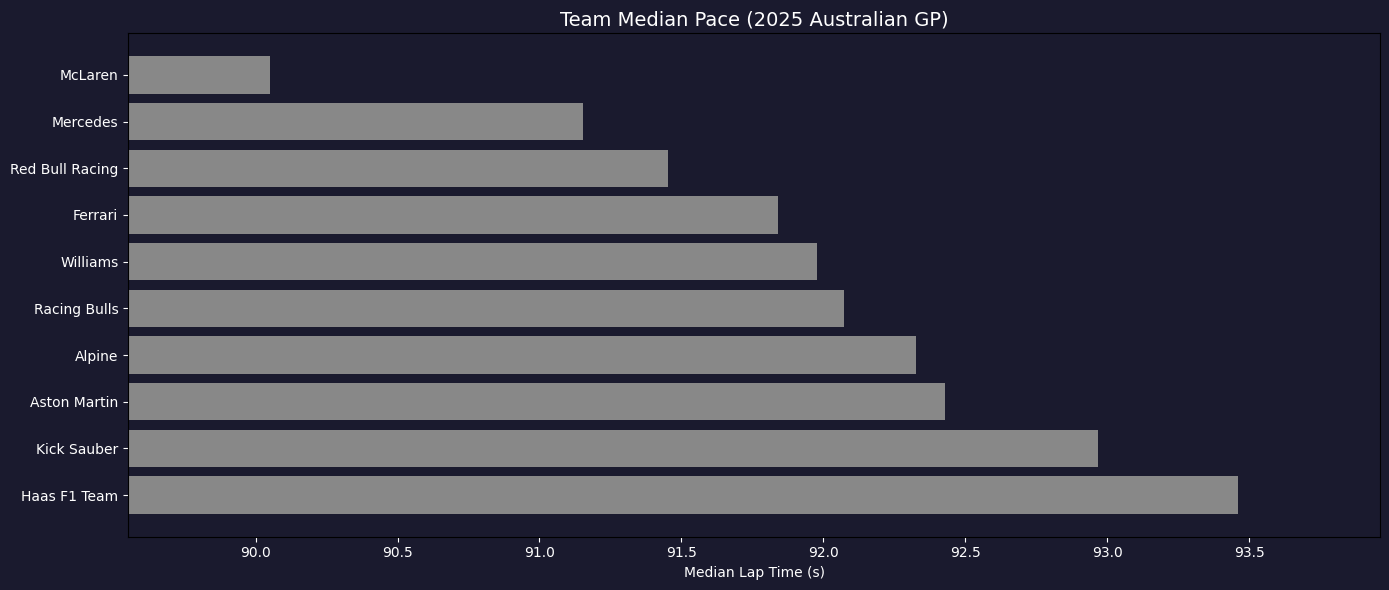

In [23]:
team_pace = clean_laps.groupby('Team')['LapTimeSeconds'].median().sort_values()

fig, ax = plt.subplots(figsize=(14, 6), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

ax.barh(team_pace.index, team_pace.values, color='#888888')
min_time = team_pace.min() - 0.5
max_time = team_pace.max() + 0.5

ax.set_title('Team Median Pace (2025 Australian GP)', color='white', fontsize=14)
ax.set_xlabel('Median Lap Time (s)', color='white')
ax.set_xlim(min_time, max_time)
ax.tick_params(colors='white')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Viz 8 — Team Pace Comparison
**What it shows:** Median lap time grouped by constructor.  
**Key insight:** McLaren leads the constructor pace battle at this circuit. There is a clear performance gap between the top 3 teams and the midfield, reflecting the 2025 constructor championship order.

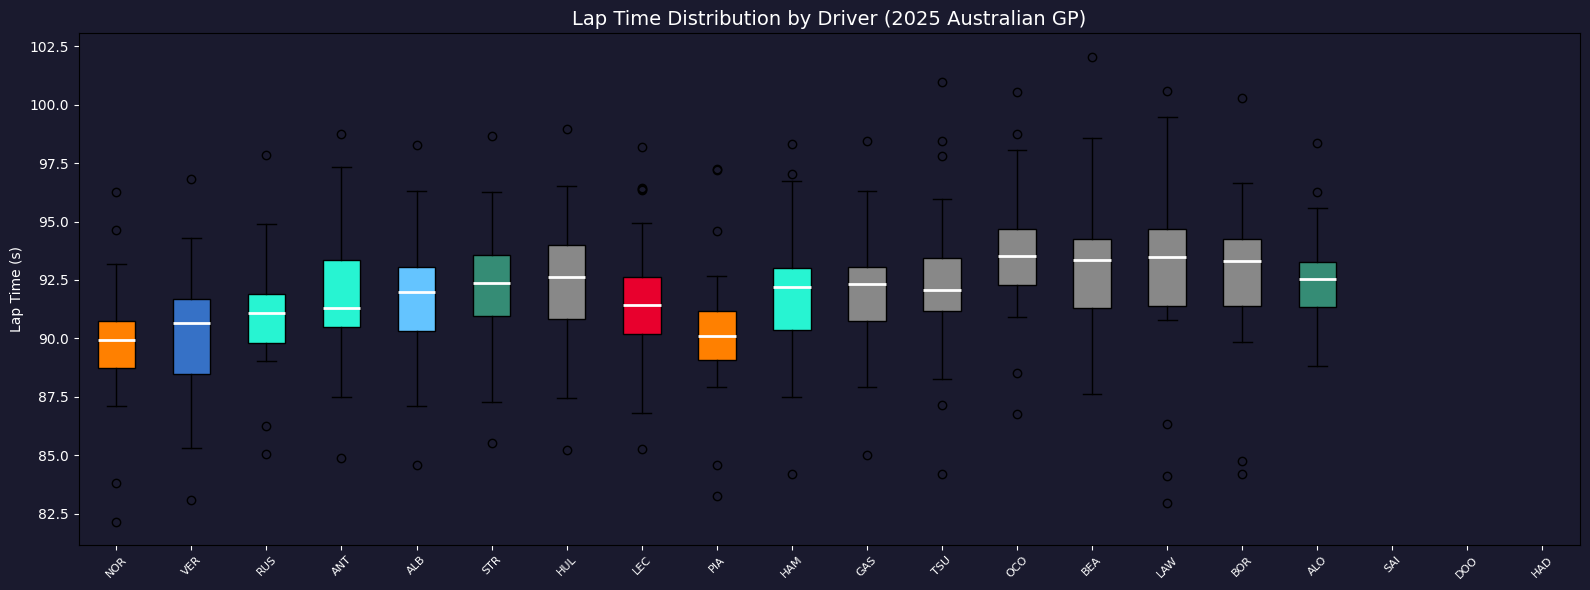

In [24]:
fig, ax = plt.subplots(figsize=(16, 6), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

data = [clean_laps[clean_laps['Driver'] == d]['LapTimeSeconds'].dropna().values
        for d in finishing_order]

bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='white', linewidth=2))

for patch, driver in zip(bp['boxes'], finishing_order):
    patch.set_facecolor(driver_colors.get(driver, '#888888'))

ax.set_xticks(range(1, len(finishing_order) + 1))
ax.set_xticklabels(finishing_order, color='white', fontsize=8, rotation=45)
ax.set_ylabel('Lap Time (s)', color='white')
ax.set_title('Lap Time Distribution by Driver (2025 Australian GP)', color='white', fontsize=14)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

## Viz 9 — Lap Time Distribution
**What it shows:** Box plot of clean lap times per driver ordered by finishing position.  
**Key insight:** NOR and VER show the lowest median times and tightest distributions — fast and consistent. Wider boxes in the midfield indicate more variable pace, often due to traffic and differing tire strategies.

## Summary
The 2025 Australian GP was dominated by McLaren with NOR leading from the front. VER was the closest challenger but lacked the pace to overtake. The early red flag compressed the field and disrupted strategies, making the tire data harder to interpret cleanly. Median lap time alone is a weak ranking metric — the box plots and compound charts together give a much fuller picture of true race pace.